## Visualization predicted DRCs with CIs

We present data from both uniform binning and quantile binning, using `comparison_method = all` (i.e. all N choose 2 possible choices of bins to compare).

In [37]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import datetime
import sys
sys.path.append("../discretized-causalpfn")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

from scipy.interpolate import interp1d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
# RMSE function
def calculate_rmse(y_pred, y_true):
    result = np.mean(np.power(y_pred - y_true, 2))
    result = np.sqrt(result)

    return result

fine_t_mesh = np.linspace(0, 1, 100)

In [39]:
# Import data
def load_data(data_name: str, binning: str): 
    name = f"EPO_df_with_CI_{data_name}_{binning}_all"
    date_string = ""
    # Deal with datetime additions in the name
    if data_name == "ADMIT-synthetic":
        date_string = "11-24_18h7m"
    elif data_name == "debt-loss": 
        if binning == "quantile":
            date_string = "11-25_11h35m"
        else:
            date_string = "11-25_11h53m"
    elif data_name == "econ-ML-ex1":
        if binning == "quantile":
            date_string = "11-24_18h3m"
        else:
            date_string = "11-24_18h5m"
    elif data_name == "vahid-linear":
        date_string = "11-24_18h5m"
    elif data_name == "vahid-nonlin":
        date_string = "11-24_18h4m"
    file_name = f"../output/{name}_{date_string}.csv"
    df = pd.read_csv(
        file_name,
        index_col=[0, 1]
    )
    
    # Load the RMSE 
    name = f"RMSE_table_{data_name}_{binning}_all"
    if data_name == "debt-loss":
        if binning == "quantile":
            date_string = "11-21_18h2m"
        else:
            date_string = "11-21_18h1m"
    else:
        date_string = "11-21_15h23m"
    file_name = f"../../Week_11-17/output/11-21/{name}_{date_string}.csv"
    rmse_df = pd.read_csv(
        file_name, 
        index_col = [0]
    )

    return df, rmse_df

In [104]:
data_name = "ADMIT-synthetic"
binning = "quantile"
save_data = True # Set to "True" to save output figures

## TRUE DRF - CHANGE THIS

# To get drf_ADMIT (the true dose-response), need to re-do DGP
def sigmoid(t): return 1. / (1. + np.exp(-1. * t))
n, d = 2000, 6
X = np.random.uniform(-1, 1, (n, d))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]
x4 = X[:, 3]
x5 = X[:, 4]
x6 = X[:, 5]
# Generate treatment 
mu_1 =  (10. * np.sin(np.maximum(x1, np.maximum(x2, x3))) + np.maximum(x3, np.maximum(x4, x5))**3)/(1. + (x1 + x5)**2) + np.sin(0.5 * x3) * (1. + np.exp(x4 - 0.5 * x3)) + x3**2 + 2. * np.sin(x4) + 2.*x5 - 6.5
T = np.random.normal(mu_1, 0.5)
T = sigmoid(T)
# Generate outcomes
mu_2 = np.cos(2 * np.pi * (T - 0.5)) * (T ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
Y = np.random.normal(mu_2, 0.5)
# Generated expected potential outcomes empirically
treatment_doses = np.linspace(0, 1, 100)
effects = []
for t in treatment_doses:
    T_intervention = t * np.ones(T.shape)
    mu_2_intervention = np.cos(2 * np.pi * (T_intervention - 0.5)) * (T_intervention ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
    effects.append(mu_2_intervention.mean())
effects = np.array(effects)
drf_true = interp1d(treatment_doses, effects) # ADMIT-synthetic


# # To get drf_debt (true dose-response), need to re-do DGP
# import sys
# sys.path.append("../../../my-work/Week_11-24/scripts")
# from debt_loss_dgp import DebtDGP, TREATMENT, OUTCOME
# generator = DebtDGP()
# n = 15000
# df_2 = generator.generate_random_financial_data(n) # df name already taken
# generator.fit_scalers(df_2)
# df_2[TREATMENT] = generator.generate_treatment(df_2, noise=True, noise_scale=0.0, treament_noise_std=0.07)
# df_2[OUTCOME + "_probs"], df_2[OUTCOME] = generator.calculate_outcome_probability(df_2, df_2[TREATMENT])
# step = 1e-2
# bin_edges = np.arange(0, 1+step, step)
# real_dose_response = generator.compute_causal_effects(df_2, bin_edges, "ate")
# # True dose-response function
# y_true_f = interp1d(bin_edges, real_dose_response)
# def drf_true(t): return y_true_f(t) # debt-loss 



#def drf_true(t): return np.float64(3.211819532711872) * t # econ-ML-ex1
#def drf_true(t): return 0.5 * t ** 2 - 2 * t # nonlin
#def drf_true(t): return 3.5 + 3 * t # linear

In [105]:
scheme = binning # Later, in code I copied from last week, I call it scheme
comparison_method = "all" 

In [106]:
df, rmse_df = load_data(data_name=data_name, binning=binning)
df.head()

estimated_epo  CI_lower_bound  CI_upper_bound
N_DISC T                                                      
2      0.014407      -0.013315       -0.022434       -0.003845
       0.441702      -0.028328       -0.039190       -0.017750
3      0.003959       0.049868        0.041809        0.057977
       0.076430      -0.048789       -0.057077       -0.040454
       0.603549      -0.025804       -0.035223       -0.016325

Text(0.5, 1.0, 'RMSE for mean EPO (ADMIT-synthetic, quantile, all)')

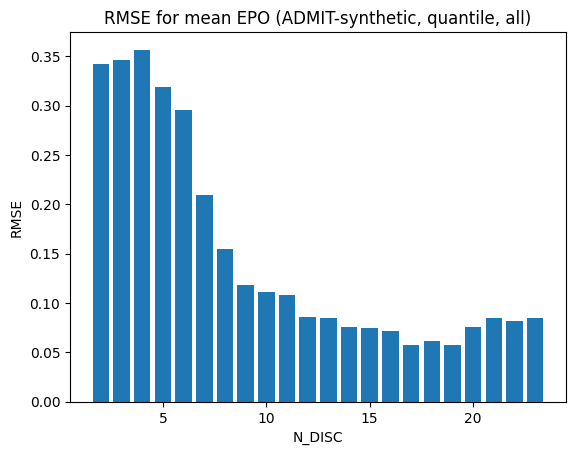

In [107]:
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO ({data_name}, {scheme}, {comparison_method})")

In [108]:
# For file naming purposes
month = datetime.datetime.now().month
date = datetime.datetime.now().day
hour = datetime.datetime.now().hour
minute = datetime.datetime.now().minute
date_string = f"{month}-{date}_{hour}h{minute}m"
file_location = "../output/"

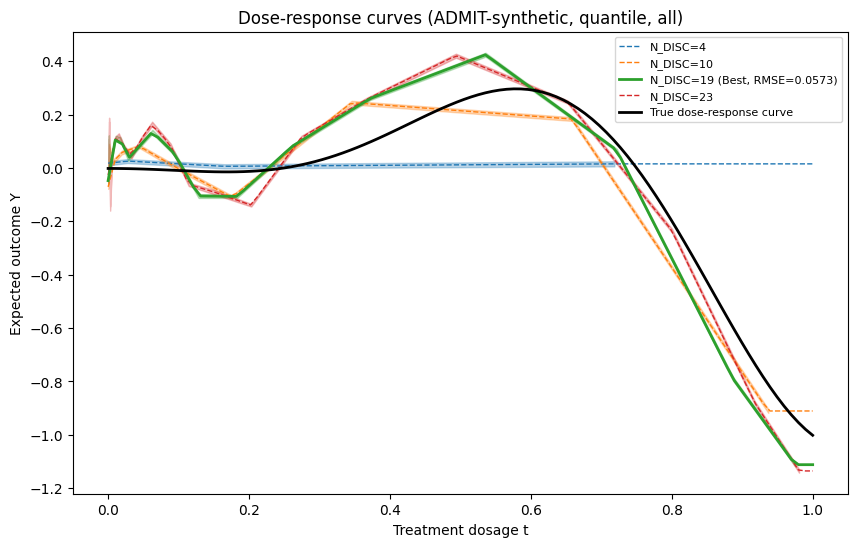

In [111]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

# for coloring
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()["color"]

N_DISC_TO_VIZ = [4, 10, 19, 23]
i = 0 # for coloring
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    t_vals = df_N.index.get_level_values(1) # get treatment values
    drf_N_pred_pts = df_N["estimated_epo"].values
    drf_N_pred = interp1d(t_vals, drf_N_pred_pts,
                          bounds_error=False,
                          fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = drf_N_pred(fine_t_mesh)
    rmse = rmse_df.loc[N_DISC, "RMSE"]
    if rmse == rmse_df.min().values: # emphasize best prediction
        plt.plot(fine_t_mesh, y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best, RMSE={rmse:.4f})", c=colors[i], zorder=14)
        # Plot CIs
        lower_bound = df_N["CI_lower_bound"].values
        upper_bound = df_N["CI_upper_bound"].values
        plt.fill_between(t_vals, lower_bound, upper_bound, color=colors[i], alpha=0.3)
    else:
        plt.plot(fine_t_mesh, y_pred, '--', linewidth=1, c=colors[i],
                 label=f"N_DISC={N_DISC}")
        # Plot CIs
        lower_bound = df_N["CI_lower_bound"].values
        upper_bound = df_N["CI_upper_bound"].values
        plt.fill_between(t_vals, lower_bound, upper_bound, color=colors[i], alpha=0.3)
    i += 1

# True dose-response curve
t_mesh = np.linspace(0, 1, 100)
y_true = drf_true(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves ({data_name}, {scheme}, {comparison_method})")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)

if save_data:
    plt.savefig(f"{file_location}/dose-response_curves_with_CI_{data_name}_{scheme}_{comparison_method}_{date_string}.png")

plt.show()